# 1. Problem Statement

The real estate market is influenced by many property-related factors, including location, property size, number of rooms, building age, land size, and available amenities. Because real estate datasets often contain a large number of variables, it can be difficult to determine which features are most strongly associated with property prices.

The purpose of this project is to identify the most important features that influence real estate prices using a machine learning model. The project will keep the modeling process simple and focus mainly on feature importance analysis rather than maximizing prediction accuracy.

## Research Question

Which features have the greatest impact on real estate prices?

## Project Objective

The main objective of this project is to use a real estate dataset to build a simple price prediction model and analyze the importance of each feature. The final result will be a ranked list of the most influential variables affecting property prices.

## Expected Outcome

By the end of this project, we expect to identify the top features that contribute most to real estate price prediction. These results can help explain which property characteristics are most valuable when estimating real estate prices.

# 2. Data Understanding

Before building a predictive model, it is important to understand the structure and quality of the dataset. This step explores the dataset by examining its dimensions, data types, missing values, and basic descriptive statistics.

The objectives of this section are:

- Understand the size of the dataset
- Identify numerical and categorical features
- Detect missing values
- Review summary statistics
- Gain an initial understanding of the variables available for analysis

The insights obtained in this stage will guide the data preparation process in the next section.

In [3]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [4]:
# Load the data
df = pd.read_csv("DuAnKhoaHocDuLieu35.csv")

df.head()

,Unnamed: 0,tweet_text,user_reported_location
0,0,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"Istanbul, Turkey"
1,1,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"Istanbul, Turkey"
2,2,قدمت الحكومة التركية العديد من التسهيلات أهمها...,istanbul
3,3,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"Istanbul, Turkey"
4,4,قدمت الحكومة التركية العديد من التسهيلات أهمها...,istanbul


In [5]:
# Dimension
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

Number of rows: 259,560
Number of columns: 3


In [6]:
# Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259560 entries, 0 to 259559
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Unnamed: 0              259560 non-null  int64 
 1   tweet_text              259560 non-null  object
 2   user_reported_location  201398 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.9+ MB


In [7]:
# Missing values
missing_values = df.isnull().sum()

missing_summary = (
    pd.DataFrame({
        "Missing Count": missing_values,
        "Missing Percentage": (missing_values / len(df)) * 100
    })
    .sort_values("Missing Percentage", ascending=False)
)

missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing Percentage
user_reported_location,58162,22.407921


In [8]:
# For numerical
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,259560.0,129779.5,74928.662273,0.0,64889.75,129779.5,194669.25,259559.0


In [9]:
# For categorical
df.describe(include='object').T

,count,unique,top,freq
tweet_text,259560,286,RT @ewZ47d1DkGvgxda: #شقق_تمليك \n#جده_صوت_ان...,48910
user_reported_location,201398,83,istanbul,40976


In [10]:
# Duplicate
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127486 (\N{REGIONAL INDICATOR SYMBOL LETTER Y}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


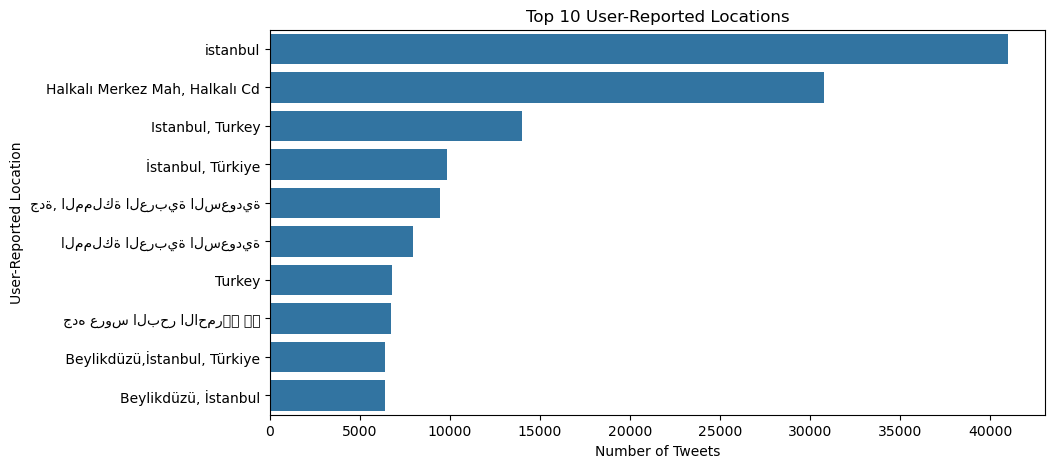

In [11]:
# Location distribution

top_locations = df["user_reported_location"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_locations.values, y=top_locations.index)

plt.title("Top 10 User-Reported Locations")
plt.xlabel("Number of Tweets")
plt.ylabel("User-Reported Location")
plt.show()

In [12]:
# Text frequency
df["tweet_text"].value_counts().head(10)

tweet_text
RT @ewZ47d1DkGvgxda: #شقق_تمليك  \n#جده_صوت_انفجار                                                                                              48910
RT @BurujPark: يطل عليكم مشروع بروج دريم بارك الذي يقع في منطقة يومرا الوجه الحديث لعروس الشمال التركي مدينة #طرابزون حيث تقام فيها اكبر ال…     8387
شركة #تيموندرو العقارية  تتمنّى لكم #جمعة_مباركة  🕌\n\n#realestate_turkey #propertyturkey #turkish_citizenship…                                  3571
قدمت الحكومة التركية العديد من التسهيلات أهمها منح الجنسية التركية للمستثمرين الأجانب ضمن شروط محددة وإن سبب هذا يع…                             3449
اللهم اجعل أيامنا كلها خيراً .. \nجمعة طيبة ..\n\n#عقارات_تركيا #شراء_عقارات #شقق_تمليك #عقارات_للبيع…                                           3432
تعد من أهم المناطق السياحية في تركيا شمال جبال طوروس، وهي تضم عدد كبير من المعالم الأثرية مثل: حديقة جوريم الوطنية…                              3426
من أخطر السلبيات هي التورط مع وكيل عقاري غير موثوق حيث أن عدداً من الناس وضعوا أموالهم في

# 3. Data Preparation

In this section, the dataset is cleaned and prepared for feature importance analysis. Since the dataset contains real estate-related tweet text instead of traditional housing price variables, the project will focus on text-based feature importance.

The goal is to identify which words or phrases in real estate-related tweets are most useful for predicting the user's reported location.

The main preparation steps include:

- Removing unnecessary columns
- Handling missing location values
- Standardizing location labels
- Removing duplicate tweet texts
- Keeping the most common locations
- Defining the feature variable and target variable

In [14]:
# Create a copy
df_clean = df.copy()

df_clean.head()

,Unnamed: 0,tweet_text,user_reported_location
0,0,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"Istanbul, Turkey"
1,1,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"Istanbul, Turkey"
2,2,قدمت الحكومة التركية العديد من التسهيلات أهمها...,istanbul
3,3,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"Istanbul, Turkey"
4,4,قدمت الحكومة التركية العديد من التسهيلات أهمها...,istanbul


In [15]:
# Drop column
df_clean = df_clean.drop(columns=["Unnamed: 0"])

df_clean.head()

,tweet_text,user_reported_location
0,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"Istanbul, Turkey"
1,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"Istanbul, Turkey"
2,قدمت الحكومة التركية العديد من التسهيلات أهمها...,istanbul
3,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"Istanbul, Turkey"
4,قدمت الحكومة التركية العديد من التسهيلات أهمها...,istanbul


In [16]:
# Remove missing location
df_clean = df_clean.dropna(subset=["user_reported_location"])

print("Rows after removing missing locations:", len(df_clean))

Rows after removing missing locations: 201398


In [17]:
# Standardize location text
df_clean["user_reported_location"] = (
    df_clean["user_reported_location"]
    .str.lower()
    .str.strip()
)

df_clean["user_reported_location"].value_counts().head(20)

user_reported_location
istanbul                                                                        40976
halkalı merkez mah, halkalı cd                                                  30761
istanbul, turkey                                                                13994
i̇stanbul, türkiye                                                               9823
جدة, المملكة العربية السعودية                                                    9423
المملكة العربية السعودية                                                         9403
turkey                                                                           6785
جده عروس البحر الاحمر🇸🇦 🇾🇪                                                       6740
beylikdüzü,i̇stanbul, türkiye                                                    6397
beylikdüzü, i̇stanbul                                                            6362
istanbul-turkey                                                                  5732
ankara, istanbul, izmir, antaly

In [18]:
# Remove duplicate
df_clean = df_clean.drop_duplicates(subset=["tweet_text"])

print("Rows after removing duplicate tweet texts:", len(df_clean))

Rows after removing duplicate tweet texts: 222


In [19]:
# Top 5 location
top_5_locations = df_clean["user_reported_location"].value_counts().head(5).index

df_clean = df_clean[df_clean["user_reported_location"].isin(top_5_locations)]

df_clean["user_reported_location"].value_counts()

user_reported_location
istanbul, turkey                                                                23
i̇stanbul, türkiye                                                              22
جدة, المملكة العربية السعودية                                                   19
ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey    17
istanbul                                                                        15
Name: count, dtype: int64

In [20]:
# Rename
df_clean = df_clean.rename(columns={
    "tweet_text": "text",
    "user_reported_location": "location"
})

df_clean.head()

,text,location
0,لا تتوقف خدماتنا في #ديدن_للعقارات_والاستثمارا...,"istanbul, turkey"
2,قدمت الحكومة التركية العديد من التسهيلات أهمها...,istanbul
9,اللهم اجعل أيامنا كلها خيراً .. \nجمعة طيبة .....,istanbul
20,من أخطر السلبيات هي التورط مع وكيل عقاري غير م...,istanbul
65,#جولة_عقارية_رقمية 📱\nنقدم لكم جولة عبر العالم...,"istanbul, turkey"


In [21]:
# Feature and target
X = df_clean["text"]
y = df_clean["location"]

print("Feature variable shape:", X.shape)
print("Target variable shape:", y.shape)

Feature variable shape: (96,)
Target variable shape: (96,)


In [22]:
# Preview
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96 entries, 0 to 257402
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      96 non-null     object
 1   location  96 non-null     object
dtypes: object(2)
memory usage: 2.2+ KB


In [23]:
# Distribution
y.value_counts()

location
istanbul, turkey                                                                23
i̇stanbul, türkiye                                                              22
جدة, المملكة العربية السعودية                                                   19
ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey    17
istanbul                                                                        15
Name: count, dtype: int64

# 4. Model Development

In this section, a simple text classification model is built to predict the user's reported location based on tweet text.

Because the dataset contains text data, the tweet text must first be converted into numerical features. This is done using TF-IDF vectorization, which assigns importance scores to words based on how frequently they appear in a tweet compared to the full dataset.

A Logistic Regression model is used because it is simple, interpretable, and useful for feature importance analysis. The goal is not to maximize prediction accuracy, but to create a model that allows us to identify which words are most important for predicting each location.

In [25]:
# Import
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 72
Testing set size: 24


In [27]:
# Convert text to numerical
vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (72, 500)
TF-IDF testing shape: (24, 500)


In [28]:
# Train
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [29]:
# Predict
y_pred = model.predict(X_test_tfidf)

y_pred[:10]

array(['جدة, المملكة العربية السعودية',
       'ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey',
       'i̇stanbul, türkiye', 'istanbul, turkey', 'istanbul, turkey',
       'i̇stanbul, türkiye', 'istanbul, turkey',
       'جدة, المملكة العربية السعودية', 'i̇stanbul, türkiye',
       'ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey'],
      dtype=object)

In [30]:
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.6667


In [31]:
# Classification report
print(classification_report(y_test, y_pred))

                                                                              precision    recall  f1-score   support

ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey       1.00      1.00      1.00         4
                                                                    istanbul       0.00      0.00      0.00         4
                                                            istanbul, turkey       0.44      0.67      0.53         6
                                                          i̇stanbul, türkiye       0.57      0.80      0.67         5
                                               جدة, المملكة العربية السعودية       1.00      0.80      0.89         5

                                                                    accuracy                           0.67        24
                                                                   macro avg       0.60      0.65      0.62        24
                                                      

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=model.classes_)

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=model.classes_,
    columns=model.classes_
)

conf_matrix_df

,"ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey",istanbul,"istanbul, turkey","i̇stanbul, türkiye","جدة, المملكة العربية السعودية"
"ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey",4,0,0,0,0
istanbul,0,0,4,0,0
"istanbul, turkey",0,0,4,2,0
"i̇stanbul, türkiye",0,0,1,4,0
"جدة, المملكة العربية السعودية",0,0,0,1,4


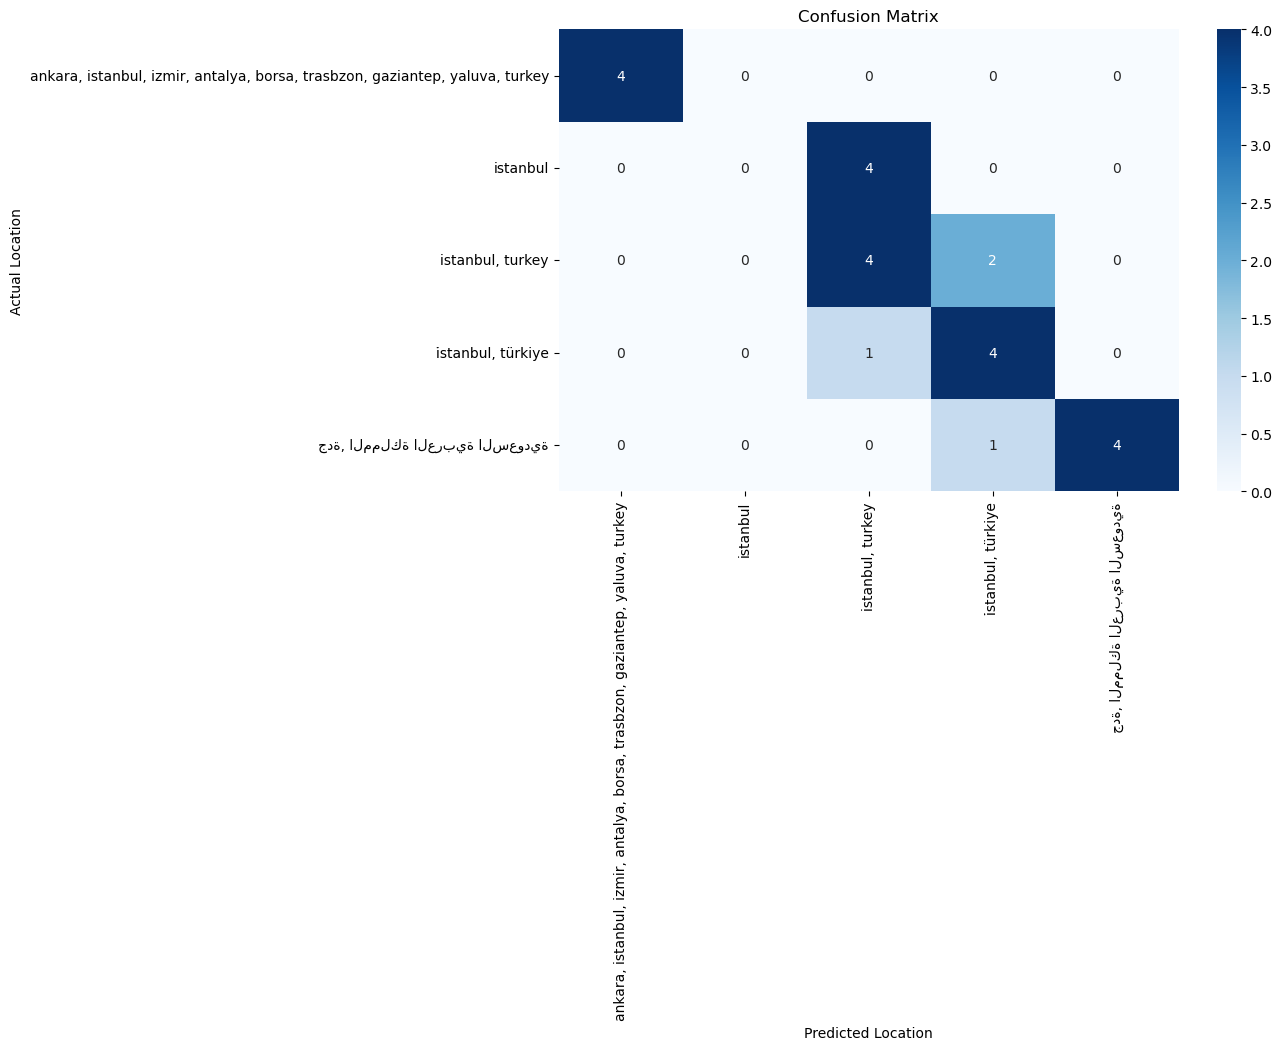

In [33]:
# Visualize
plt.figure(figsize=(10, 6))

sns.heatmap(
    conf_matrix_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Location")
plt.ylabel("Actual Location")
plt.show()

In [34]:
# Save
feature_names = vectorizer.get_feature_names_out()

print("Number of text features:", len(feature_names))
print(feature_names[:20])

Number of text features: 500
['118' '118 sqm' '174' '174 متر' '2021' '240الف' '240الف ريال' '3دورات'
 '3دورات مياه' '3غرف' '3غرف صاله' '4غرف' '4غرف صالة' '5غرف' '5غرف مع'
 'alrifai_jed' 'ankara' 'ankara 118' 'ankara pursaklar' 'apartment']


# 5. Feature Importance Analysis

The primary objective of this project is to identify the words and phrases that contribute most strongly to predicting a user's reported location.

The Logistic Regression model assigns coefficients to each TF-IDF feature. Features with larger coefficients have a stronger influence on the prediction of a specific location.

This section extracts and ranks the most important text features and visualizes the most influential words for each location category.

In [36]:
# Examine structure
print("Number of classes:", len(model.classes_))
print("Classes:")
print(model.classes_)

Number of classes: 5
Classes:
['ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey'
 'istanbul' 'istanbul, turkey' 'i̇stanbul, türkiye'
 'جدة, المملكة العربية السعودية']


In [37]:
# Create coefficient
coef_df = pd.DataFrame(
    model.coef_.T,
    index=feature_names,
    columns=model.classes_
)

coef_df.head()

,"ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey",istanbul,"istanbul, turkey","i̇stanbul, türkiye","جدة, المملكة العربية السعودية"
118,0.169395,-0.035331,-0.046549,-0.048603,-0.038911
118 sqm,0.169395,-0.035331,-0.046549,-0.048603,-0.038911
174,-0.036982,-0.039592,0.061894,0.058321,-0.043641
174 متر,-0.036982,-0.039592,0.061894,0.058321,-0.043641
2021,0.225647,-0.042568,-0.060412,-0.070553,-0.052114


In [38]:
# Top 10 feature for each location
for location in model.classes_:

    print("\n" + "="*80)
    print(f"Top Features for: {location}")
    print("="*80)

    top_features = (
        coef_df[location]
        .sort_values(ascending=False)
        .head(10)
    )

    print(top_features)


Top Features for: ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey
شقة                         0.897823
شقة_للبيع                   0.712354
شقة_للبيع شقة               0.712354
الخصائص_للبيع               0.644401
شقة شقق_للبيع               0.614723
شقق_للبيع شقق               0.614723
شقق_للبيع                   0.573143
for                         0.552504
ankara                      0.552504
الخصائص_للبيع عقار_للبيع    0.499618
Name: ankara, istanbul, izmir, antalya, borsa, trasbzon, gaziantep, yaluva, turkey, dtype: float64

Top Features for: istanbul
أن               0.689259
العقار           0.528726
حيث              0.492525
مدينة            0.489926
مدينة اسطنبول    0.489926
من               0.418610
إلى              0.406404
إضافة            0.377130
إضافة إلى        0.377130
غير              0.359321
Name: istanbul, dtype: float64

Top Features for: istanbul, turkey
فرصة                          0.495646
استثمار                       0.445320
ال

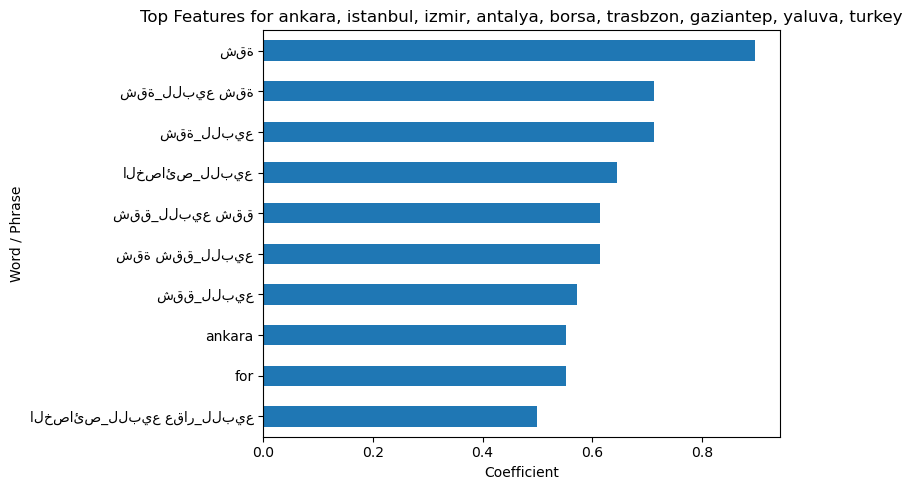

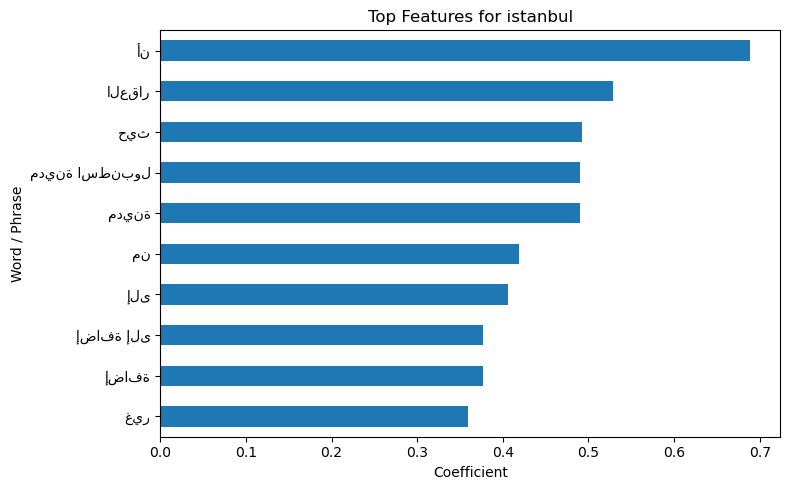

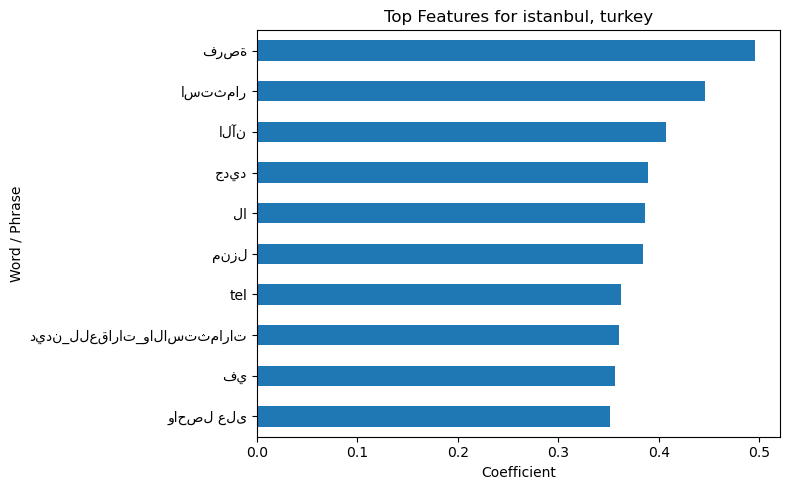

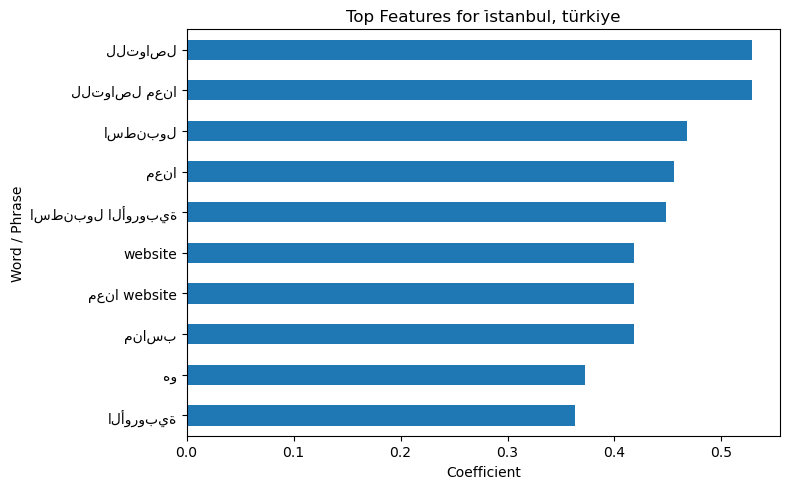

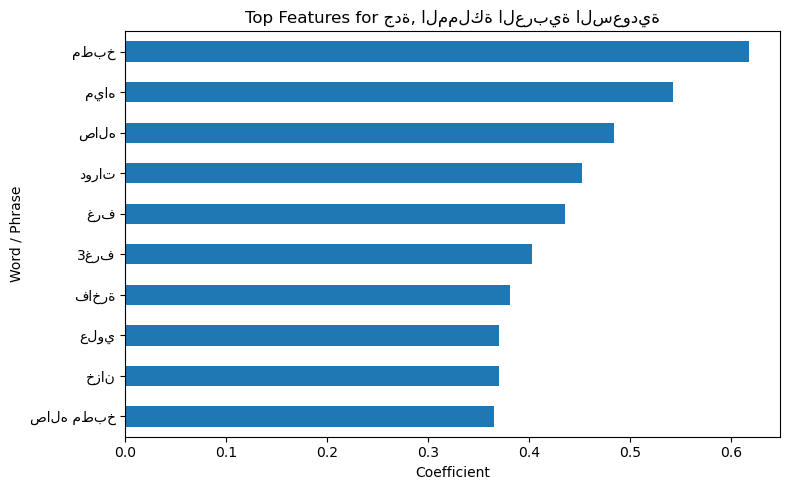

In [39]:
# Visualize top feature for each location
for location in model.classes_:

    top_features = (
        coef_df[location]
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(8,5))

    top_features.sort_values().plot(kind="barh")

    plt.title(f"Top Features for {location}")
    plt.xlabel("Coefficient")
    plt.ylabel("Word / Phrase")

    plt.tight_layout()
    plt.show()

In [40]:
# Global feature importance
global_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": np.mean(np.abs(model.coef_), axis=0)
})

global_importance = global_importance.sort_values(
    "importance",
    ascending=False
)

global_importance.head(20)

,feature,importance
188,شقة,0.359129
200,شقة_للبيع,0.284942
201,شقة_للبيع شقة,0.284942
50,أن,0.275703
204,شقق,0.266740
446,مشروع,0.260562
93,الخصائص_للبيع,0.257760
461,من,0.256769
448,مطبخ,0.246897
219,شقق_للبيع شقق,0.245889


In [41]:
# Top 20
top20 = global_importance.head(20)

top20

,feature,importance
188,شقة,0.359129
200,شقة_للبيع,0.284942
201,شقة_للبيع شقة,0.284942
50,أن,0.275703
204,شقق,0.266740
446,مشروع,0.260562
93,الخصائص_للبيع,0.257760
461,من,0.256769
448,مطبخ,0.246897
219,شقق_للبيع شقق,0.245889


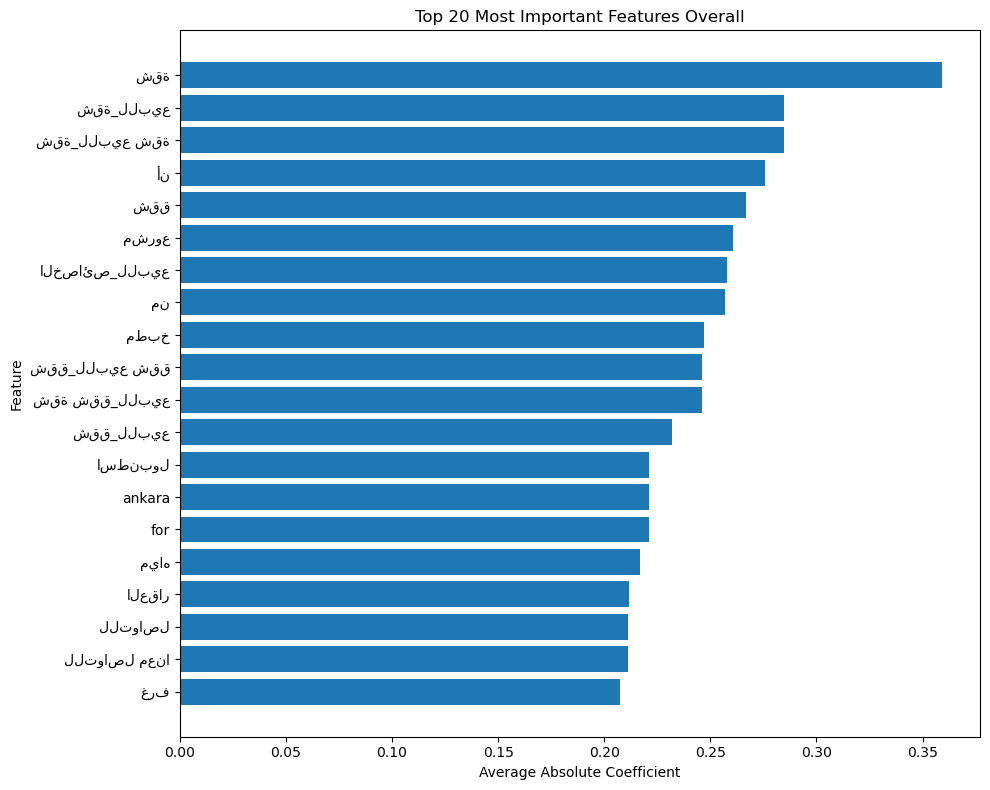

In [42]:
# Visualize
plt.figure(figsize=(10,8))

plt.barh(
    top20["feature"][::-1],
    top20["importance"][::-1]
)

plt.title("Top 20 Most Important Features Overall")
plt.xlabel("Average Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [43]:
# Export
global_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [44]:
# Top 30
global_importance.head(30)

,feature,importance
188,شقة,0.359129
200,شقة_للبيع,0.284942
201,شقة_للبيع شقة,0.284942
50,أن,0.275703
204,شقق,0.266740
446,مشروع,0.260562
93,الخصائص_للبيع,0.257760
461,من,0.256769
448,مطبخ,0.246897
219,شقق_للبيع شقق,0.245889


In [45]:
# Project insight
print("Top 10 Most Important Features")

global_importance.head(10)

Top 10 Most Important Features


,feature,importance
188,شقة,0.359129
200,شقة_للبيع,0.284942
201,شقة_للبيع شقة,0.284942
50,أن,0.275703
204,شقق,0.266740
446,مشروع,0.260562
93,الخصائص_للبيع,0.257760
461,من,0.256769
448,مطبخ,0.246897
219,شقق_للبيع شقق,0.245889


# 6. Discussion and Interpretation

The primary objective of this project was to identify the most important text features associated with user-reported locations in a real estate-related Twitter dataset.

A Logistic Regression model was trained using TF-IDF text features and achieved an accuracy of approximately 66.7%. Although predictive performance was not the primary focus, the model provided useful insights into which words and phrases contributed most strongly to location prediction.

## Key Findings

The feature importance analysis revealed that several real estate-related terms were highly influential in distinguishing locations. The most important features across all locations included:

- شقة (apartment)
- شقة_للبيع (apartment for sale)
- شقق (apartments)
- مشروع (project)
- الخصائص_للبيع (properties for sale)
- مطبخ (kitchen)
- غرف (rooms)
- العقار (real estate/property)
- اسطنبول (Istanbul)
- للتواصل معنا (contact us)

These features indicate that property advertisements, housing descriptions, and location-specific terminology are strong indicators of geographic origin.

## Location-Specific Insights

### Istanbul Region

Tweets associated with Istanbul frequently contained words related to real estate investment, city references, and property discussions. Important features included:

- اسطنبول
- مدينة اسطنبول
- العقار
- حيث
- مدينة

These terms suggest a focus on urban real estate and investment opportunities.

### Istanbul, Turkey

Important features included:

- فرصة (opportunity)
- استثمار (investment)
- منزل (home)
- ديدن_للعقارات_والاستثمارات

These terms indicate that promotional and investment-oriented content was common for this location.

### Istanbul, Türkiye

The model identified communication-oriented terms such as:

- للتواصل معنا
- للتواصل
- website
- اسطنبول الأوروبية

These features suggest that many tweets were generated from business advertisements or property agencies.

### Jeddah, Saudi Arabia

The most important features were highly property-specific:

- مطبخ (kitchen)
- مياه (water)
- غرف (rooms)
- صاله (living room)

These words describe property characteristics and housing specifications commonly used in residential advertisements.

### Multi-City Turkey Region

The model associated this location with terms such as:

- شقة
- شقة_للبيع
- شقق_للبيع
- ankara

These features indicate strong connections to property listing advertisements across multiple Turkish cities.

## Interpretation

Overall, the results demonstrate that real estate terminology is highly informative for location prediction within this dataset. Property-related words, housing specifications, and city references were consistently among the most influential features.

The findings suggest that geographic differences in advertising language and property descriptions can be successfully captured using machine learning feature importance analysis.

# 7. Conclusion

This project explored a real estate-related Twitter dataset with the objective of identifying the most important features for predicting user-reported locations.

After cleaning and preparing the data, a Logistic Regression classifier was trained using TF-IDF text features. The model achieved an accuracy of approximately 66.7%, providing a reasonable foundation for feature importance analysis.

The results showed that property-related terms such as apartment listings, property descriptions, housing features, and city-specific references were among the most influential predictors. Features such as شقة (apartment), شقة_للبيع (apartment for sale), مشروع (project), مطبخ (kitchen), and اسطنبول (Istanbul) contributed strongly to location classification.

The analysis demonstrates that text-based feature importance techniques can effectively identify the words and phrases that distinguish real estate discussions across different geographic locations. These findings provide insight into regional differences in real estate advertising language and property marketing strategies.

Future work could explore larger datasets, more advanced text preprocessing techniques, and alternative machine learning models to further improve predictive performance and interpretability.